In [1]:
import os
from pathlib import Path
cwd = Path.cwd()

if cwd.name == "notebooks":
    os.chdir(cwd.parent)

In [2]:
import os, math, json
from pathlib import Path
import numpy as np
import torch
import pandas as pd

import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.spatial.distance import jensenshannon

In [ ]:
import re
import numpy as np
import torch
import matplotlib.pyplot as plt

RESULTS_PATH = "data/experiments/group_emb_patching/vitbase_neutrality/group_embedding_patching_results.pt"
results = torch.load(RESULTS_PATH, map_location="cpu", weights_only=False)

print("Top keys:", list(results.keys()))
print("Original keys:", list(results["original"].keys()))
print("Corrupted keys:", list(results["corrupted"].keys()))
print("Patched combos:", len(results["patched"]))
print("Example combo keys:", list(results["patched"].keys())[:5])

emotion_map = results.get("emotion_map", {})
combo_names = list(results["patched"].keys())

def _to_np(x):
    if x is None: 
        return None
    if isinstance(x, np.ndarray):
        return x
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.array(x)

orig_final = _to_np(results["original"]["final_probs"])[0]  
corr_final = _to_np(results["corrupted"]["final_probs"])[0] 
C = orig_final.shape[0]
print("C:", C)

def pretty_label(i):
    if isinstance(emotion_map, dict) and len(emotion_map)>0:
        return str(emotion_map.get(int(i), i))
    return str(i)


Top keys: ['original', 'corrupted', 'patched', 'emotion_map', 'groups_json_path', 'file_key', 'groups', 'combo_names']
Original keys: ['metadata', 'layer_probs', 'final_probs']
Corrupted keys: ['metadata', 'layer_probs', 'final_probs']
Patched combos: 15
Example combo keys: ['skin', 'brows', 'lips', 'neck', 'skin+brows']
C: 6


In [ ]:
TRUE_C = int(orig_final.argmax())
print("Using TRUE_C:", TRUE_C, pretty_label(TRUE_C))

def safe_probs(p, eps=1e-12):
    p = np.asarray(p, dtype=np.float64)
    p = np.clip(p, eps, 1.0)
    return p / p.sum()

def kl(p, q):
    p = safe_probs(p); q = safe_probs(q)
    return float(np.sum(p * (np.log(p) - np.log(q))))

def js(p, q):
    p = safe_probs(p); q = safe_probs(q)
    m = 0.5*(p+q)
    return 0.5*kl(p,m) + 0.5*kl(q,m)

def l1(p, q):
    p = safe_probs(p); q = safe_probs(q)
    return float(np.sum(np.abs(p-q)))

def top2(p):
    idx = np.argsort(p)[::-1]
    return int(idx[0]), float(p[idx[0]]), int(idx[1]), float(p[idx[1]])


Using TRUE_C: 1 happiness


In [ ]:
layer_keys = sorted(results["original"]["layer_probs"].keys(), key=lambda x: int(x.split("_")[1]))
layer_ids = [int(k.split("_")[1]) for k in layer_keys]
L = len(layer_keys)

print("Layers in probes:", layer_ids[:5], "... total:", L)

final_p_correct = np.zeros((len(combo_names),), dtype=np.float32)
final_delta_correct = np.zeros((len(combo_names),), dtype=np.float32)
final_js_to_orig = np.zeros((len(combo_names),), dtype=np.float32)
final_kl_to_orig = np.zeros((len(combo_names),), dtype=np.float32)
final_l1_to_orig = np.zeros((len(combo_names),), dtype=np.float32)
final_pred = np.zeros((len(combo_names),), dtype=np.int32)

layer_delta_correct = np.zeros((len(combo_names), L), dtype=np.float32)

orig_layer_probs = {k: _to_np(results["original"]["layer_probs"][k])[0] for k in layer_keys}
orig_layer_pc = np.array([orig_layer_probs[k][TRUE_C] for k in layer_keys], dtype=np.float32)

orig_pc_final = float(orig_final[TRUE_C])

for i, combo in enumerate(combo_names):
    patched = results["patched"][combo]
    
    p_final = _to_np(patched["final_probs"])[0]
    final_p_correct[i] = float(p_final[TRUE_C])
    final_delta_correct[i] = float(p_final[TRUE_C] - orig_pc_final)
    final_js_to_orig[i] = js(p_final, orig_final)
    final_kl_to_orig[i] = kl(p_final, orig_final)
    final_l1_to_orig[i] = l1(p_final, orig_final)
    final_pred[i] = int(p_final.argmax())

    for j, lk in enumerate(layer_keys):
        p_layer = _to_np(patched["layer_probs"][lk])[0]
        layer_delta_correct[i, j] = float(p_layer[TRUE_C] - orig_layer_probs[lk][TRUE_C])

print("Built matrices:")
print(" layer_delta_correct:", layer_delta_correct.shape)


Layers in probes: [1, 2, 3, 4, 5] ... total: 11
Built matrices:
 layer_delta_correct: (15, 11)


In [7]:
orig_pred = int(orig_final.argmax())
corr_pred = int(corr_final.argmax())
print("orig_pred:", orig_pred, pretty_label(orig_pred))
print("corr_pred:", corr_pred, pretty_label(corr_pred))

rows = []
for i, combo in enumerate(combo_names):
    p_final = _to_np(results["patched"][combo]["final_probs"])[0]
    a0, p0, a1, p1 = top2(p_final)
    rows.append({
        "combo": combo,
        "delta_p_correct": float(final_delta_correct[i]),
        "p_correct": float(final_p_correct[i]),
        "pred": int(final_pred[i]),
        "pred_name": pretty_label(int(final_pred[i])),
        "p_pred": float(p0),
        "runnerup": pretty_label(a1),
        "p_runnerup": float(p1),
        "JS_to_orig": float(final_js_to_orig[i]),
        "L1_to_orig": float(final_l1_to_orig[i]),
        "flip_from_orig": int(final_pred[i] != orig_pred),
        "flip_to_corr": int(final_pred[i] == corr_pred),
    })

rows_sorted = sorted(rows, key=lambda r: r["delta_p_correct"])  # most negative first
print("Top 15 most damaging (most negative Δp(correct)):")
for r in rows_sorted[:15]:
    print(f"{r['combo']:<25} Δp={r['delta_p_correct']:+.6f}  p_correct={r['p_correct']:.6f}  "
          f"pred={r['pred_name']} (p={r['p_pred']:.4f})  JS={r['JS_to_orig']:.4f}  flip={r['flip_from_orig']}")


orig_pred: 1 happiness
corr_pred: 2 sadness
Top 15 most damaging (most negative Δp(correct)):
skin                      Δp=-1.000000  p_correct=0.000000  pred=sadness (p=1.0000)  JS=0.6931  flip=1
skin+brows                Δp=-1.000000  p_correct=0.000000  pred=sadness (p=1.0000)  JS=0.6931  flip=1
skin+lips                 Δp=-1.000000  p_correct=0.000000  pred=sadness (p=1.0000)  JS=0.6931  flip=1
skin+neck                 Δp=-1.000000  p_correct=0.000000  pred=sadness (p=0.9998)  JS=0.6931  flip=1
lips+neck                 Δp=-1.000000  p_correct=0.000000  pred=sadness (p=0.9984)  JS=0.6931  flip=1
skin+brows+lips           Δp=-1.000000  p_correct=0.000000  pred=sadness (p=1.0000)  JS=0.6931  flip=1
skin+brows+neck           Δp=-1.000000  p_correct=0.000000  pred=sadness (p=0.9998)  JS=0.6931  flip=1
skin+lips+neck            Δp=-1.000000  p_correct=0.000000  pred=sadness (p=0.9998)  JS=0.6931  flip=1
brows+lips+neck           Δp=-1.000000  p_correct=0.000000  pred=sadness (p=0.9999

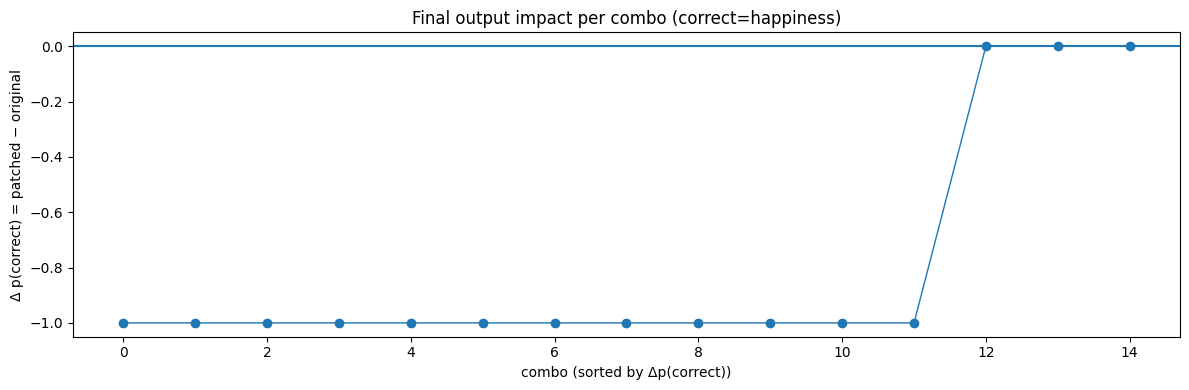

Most damaging: skin Δp= -1.0
Least damaging: brows Δp= 8.14975e-10


In [ ]:
order = np.argsort(final_delta_correct)
vals = final_delta_correct[order]
names = [combo_names[i] for i in order]

plt.figure(figsize=(12, 4))
plt.plot(vals, marker="o", linewidth=1)
plt.axhline(0.0)
plt.xlabel("combo (sorted by Δp(correct))")
plt.ylabel("Δ p(correct) = patched − original")
plt.title(f"Final output impact per combo (correct={pretty_label(TRUE_C)})")
plt.tight_layout()
plt.show()

print("Most damaging:", names[0], "Δp=", vals[0])
print("Least damaging:", names[-1], "Δp=", vals[-1])


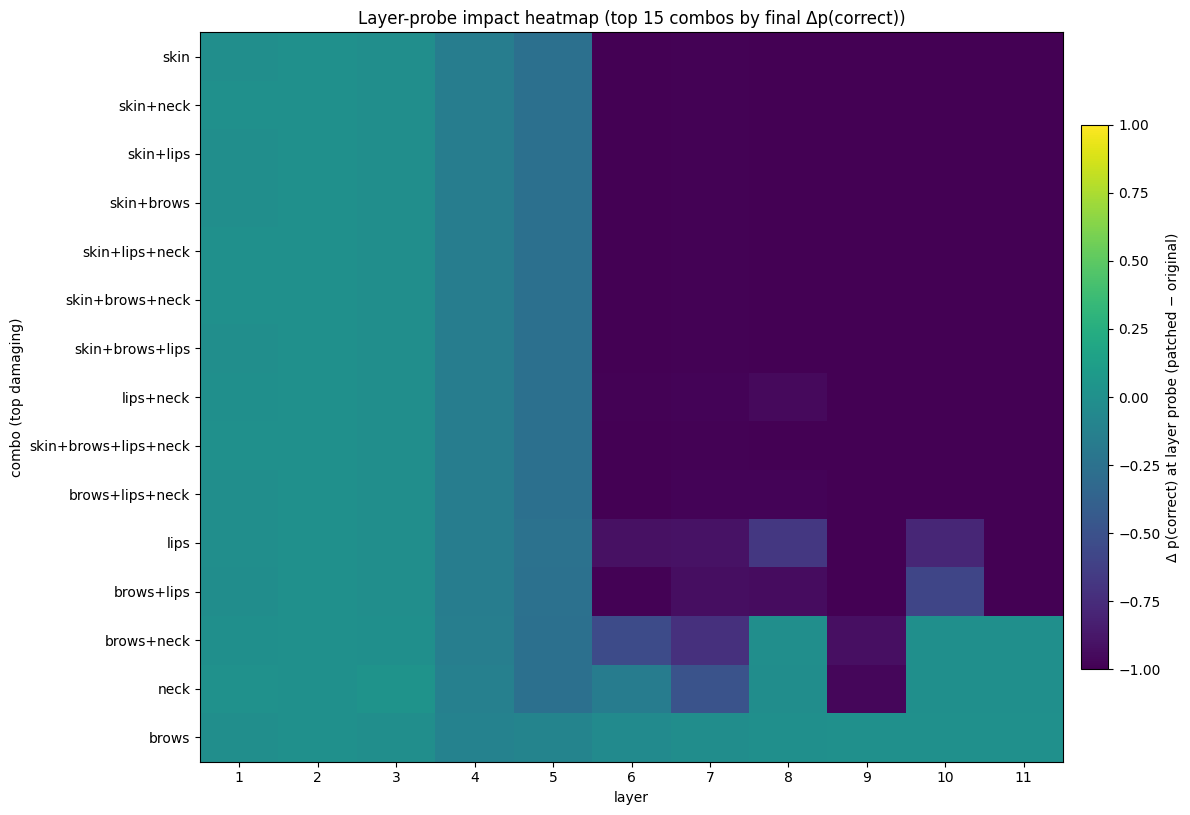

In [ ]:
TOP_K = min(30, len(combo_names))
top_idx = order[:TOP_K]
M = layer_delta_correct[top_idx, :]  # [K, L]
combo_top = [combo_names[i] for i in top_idx]

finite = M[np.isfinite(M)]
v = float(np.quantile(np.abs(finite), 0.99)) if finite.size else 1e-6
v = max(v, 1e-6)

plt.figure(figsize=(12, 0.35*TOP_K + 3))
im = plt.imshow(M, aspect="auto", interpolation="nearest", vmin=-v, vmax=v)
plt.colorbar(im, fraction=0.03, pad=0.02, label="Δ p(correct) at layer probe (patched − original)")
plt.yticks(np.arange(TOP_K), combo_top)
plt.xticks(np.arange(L), layer_ids, rotation=0)
plt.xlabel("layer")
plt.ylabel("combo (top damaging)")
plt.title(f"Layer-probe impact heatmap (top {TOP_K} combos by final Δp(correct))")
plt.tight_layout()
plt.show()


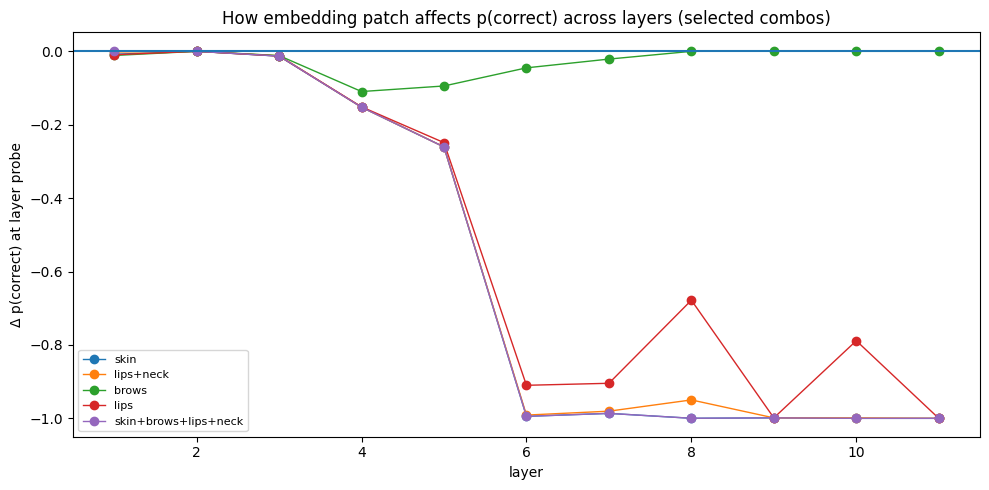

In [ ]:
sel = []
sel.append(order[0])
sel.append(order[len(order)//2])
sel.append(order[-1])

if len(order) > 5:
    sel += list(np.random.choice(order[1:-1], size=2, replace=False))

plt.figure(figsize=(10, 5))
for idx in sel:
    plt.plot(layer_ids, layer_delta_correct[idx], marker="o", linewidth=1, label=combo_names[idx])
plt.axhline(0.0)
plt.xlabel("layer")
plt.ylabel("Δ p(correct) at layer probe")
plt.title("How embedding patch affects p(correct) across layers (selected combos)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


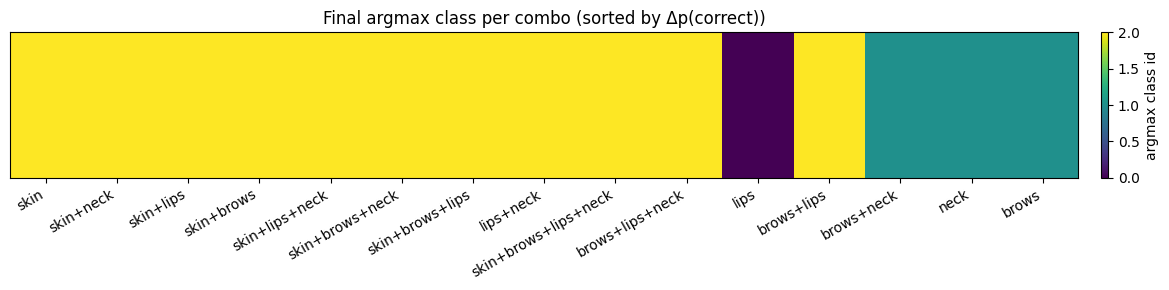

Pred distribution across combos:
sadness: 11
happiness: 3
neutrality: 1


In [ ]:
pred_sorted = final_pred[order]

plt.figure(figsize=(12, 3))
im = plt.imshow(pred_sorted.reshape(1, -1), aspect="auto", interpolation="nearest")
plt.colorbar(im, fraction=0.03, pad=0.02, label="argmax class id")
plt.yticks([])
plt.xticks(np.arange(len(order))[::max(1,len(order)//10)], [combo_names[i] for i in order][::max(1,len(order)//10)], rotation=30, ha="right")
plt.title("Final argmax class per combo (sorted by Δp(correct))")
plt.tight_layout()
plt.show()

# quick counts
unique, counts = np.unique(final_pred, return_counts=True)
print("Pred distribution across combos:")
for u,cnt in sorted(zip(unique, counts), key=lambda x: -x[1]):
    print(f"{pretty_label(u)}: {cnt}")


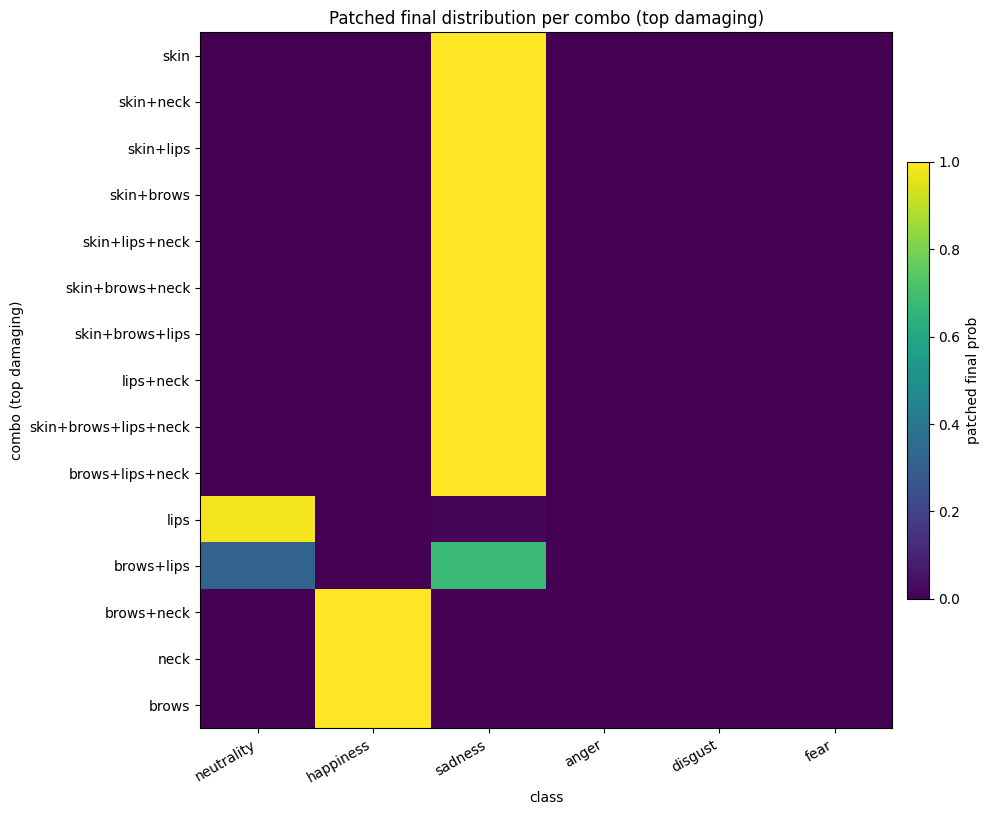

In [12]:
TOP_K = min(25, len(combo_names))
top_idx = order[:TOP_K]
combo_top = [combo_names[i] for i in top_idx]

F = np.zeros((TOP_K, C), dtype=np.float32)
for r, idx in enumerate(top_idx):
    F[r] = _to_np(results["patched"][combo_names[idx]]["final_probs"])[0]

plt.figure(figsize=(10, 0.35*TOP_K + 3))
im = plt.imshow(F, aspect="auto", interpolation="nearest", vmin=0.0, vmax=1.0)
plt.colorbar(im, fraction=0.03, pad=0.02, label="patched final prob")
plt.yticks(np.arange(TOP_K), combo_top)
plt.xticks(np.arange(C), [pretty_label(i) for i in range(C)], rotation=30, ha="right")
plt.xlabel("class")
plt.ylabel("combo (top damaging)")
plt.title("Patched final distribution per combo (top damaging)")
plt.tight_layout()
plt.show()


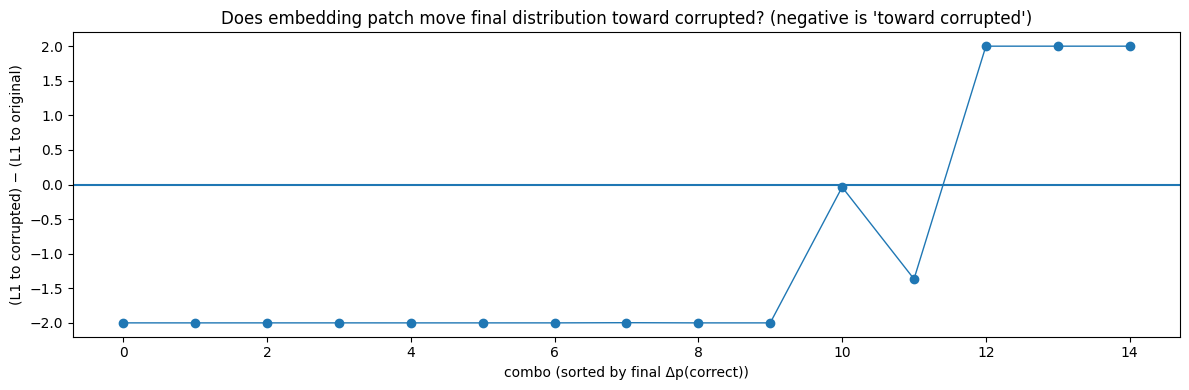

Most toward corrupted (min score): brows+lips+neck score= -1.999909520149231


In [ ]:
to_corr = np.zeros((len(combo_names),), dtype=np.float32)
to_orig = np.zeros((len(combo_names),), dtype=np.float32)

for i, combo in enumerate(combo_names):
    p_final = _to_np(results["patched"][combo]["final_probs"])[0]
    to_corr[i] = l1(p_final, corr_final)
    to_orig[i] = l1(p_final, orig_final)

score = to_corr - to_orig
score_sorted = score[order]

plt.figure(figsize=(12,4))
plt.plot(score_sorted, marker="o", linewidth=1)
plt.axhline(0.0)
plt.xlabel("combo (sorted by final Δp(correct))")
plt.ylabel("(L1 to corrupted) − (L1 to original)")
plt.title("Does embedding patch move final distribution toward corrupted? (negative is 'toward corrupted')")
plt.tight_layout()
plt.show()

best = combo_names[order[np.argmin(score_sorted)]]
print("Most toward corrupted (min score):", best, "score=", float(score[combo_names.index(best)]))


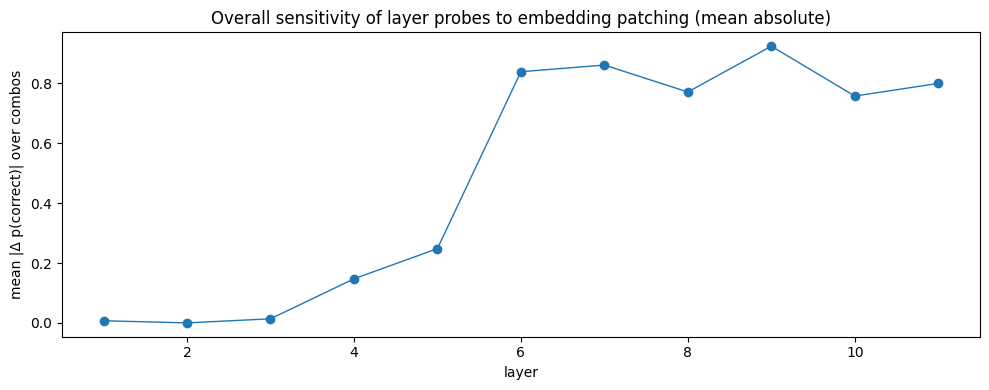

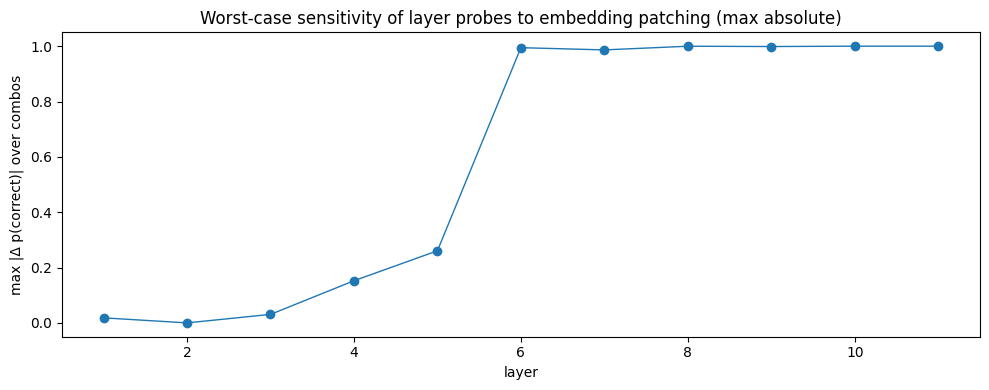

In [ ]:
mean_abs = np.mean(np.abs(layer_delta_correct), axis=0)  # [L]
plt.figure(figsize=(10,4))
plt.plot(layer_ids, mean_abs, marker="o", linewidth=1)
plt.xlabel("layer")
plt.ylabel("mean |Δ p(correct)| over combos")
plt.title("Overall sensitivity of layer probes to embedding patching (mean absolute)")
plt.tight_layout()
plt.show()

max_abs = np.max(np.abs(layer_delta_correct), axis=0)
plt.figure(figsize=(10,4))
plt.plot(layer_ids, max_abs, marker="o", linewidth=1)
plt.xlabel("layer")
plt.ylabel("max |Δ p(correct)| over combos")
plt.title("Worst-case sensitivity of layer probes to embedding patching (max absolute)")
plt.tight_layout()
plt.show()
